In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib
import itertools
import random

font = {'size'   : 16}

matplotlib.rc('font', **font)

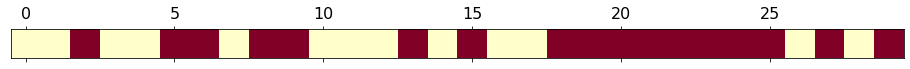

In [3]:
n = 30 
testpercent = 0.3

V = np.random.random(n)
V = V<0.66

plt.matshow(V.reshape(1,-1),cmap = 'YlOrRd')
ax = plt.gca()
ax.axes.yaxis.set_visible(False)

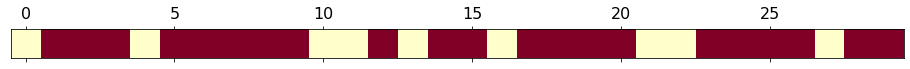

In [4]:
A = np.concatenate([np.array(range(n)).reshape(-1,1),np.ones((n,1))], axis = 1)
np.random.shuffle(A)
A[:int(testpercent*n),1] = 0
A= A[np.argsort(A[:, 0])]
V = A[:,1].T

plt.matshow(V.reshape(1,-1),cmap = 'YlOrRd')
ax = plt.gca()
ax.axes.yaxis.set_visible(False)

In [5]:
for seed in range(5):
    np.random.seed(seed)
    A = np.concatenate([np.array(range(n)).reshape(-1,1),np.ones((n,1))], axis = 1)
    np.random.shuffle(A)
    A[:int(testpercent*n),1] = 0
    A= A[np.argsort(A[:, 0])]
    V = A[:,1].T
    plt.matshow(V.reshape(1,-1),cmap = 'YlOrRd')
    ax = plt.gca()
    ax.axes.yaxis.set_visible(False)
#     plt.savefig('CV-subset'+str(seed)+'.png', bbox_inches = 'tight')
    plt.clf()

<Figure size 1152x144 with 0 Axes>

<Figure size 1152x144 with 0 Axes>

<Figure size 1152x144 with 0 Axes>

<Figure size 1152x144 with 0 Axes>

<Figure size 1152x144 with 0 Axes>

# LOOCV

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1.
 1. 0. 1. 1. 0. 0.]


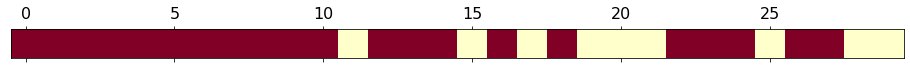

In [8]:
print(V)
plt.matshow(V.reshape(1,-1),cmap = 'YlOrRd')
ax = plt.gca()
ax.axes.yaxis.set_visible(False)

In [20]:
for i in [0,1,2,3,4,n-1]:
    V = np.ones((1,n))
    V[0,i] = 0
    plt.matshow(V.reshape(1,-1),cmap = 'YlOrRd')
    ax = plt.gca()
    ax.axes.yaxis.set_visible(False)
    if i>0:
        ax.axes.xaxis.set_visible(False)
    plt.savefig('LOOCV-subset'+str(i)+'.png', bbox_inches = 'tight')
    plt.clf()

<Figure size 1152x144 with 0 Axes>

<Figure size 1152x144 with 0 Axes>

<Figure size 1152x144 with 0 Axes>

<Figure size 1152x144 with 0 Axes>

<Figure size 1152x144 with 0 Axes>

<Figure size 1152x144 with 0 Axes>

In [11]:
V = np.ones((1,n))
print(V)
#     V[1,i] = 0
#     plt.matshow(V.reshape(1,-1),cmap = 'YlOrRd')

[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1.]]


In [15]:
V[0,i]

1.0

# Making a homework problem 

Goal: 
- Get the auto data set 
- Get them to do linear regression predicting horsepower from mpg 
- Get them to do the LOO version on their own 

In [39]:
# As always, we start with our favorite standard imports. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline

from sklearn.metrics import mean_squared_error as MSE
from sklearn.linear_model import LinearRegression


In [48]:
auto = pd.read_csv('Auto.csv')
auto = auto.replace('?', np.nan)
auto = auto.dropna()
auto.horsepower = auto.horsepower.astype('int')

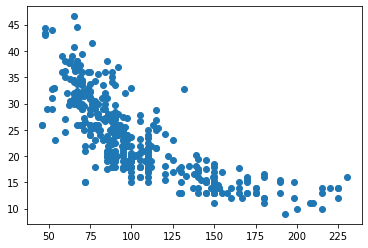

In [49]:
plt.scatter(auto.horsepower, auto.mpg)

In [107]:
Error  = 0

for i in auto.index:
    reg = LinearRegression()
    # Then we pass in the data we want it to use to fit.
    X = np.array(auto.horsepower.drop(index = i)).reshape(-1,1)
    y = np.array(auto.mpg.drop(index = i)).reshape(-1,1)
    reg.fit(X,y)

    e = MSE( reg.predict([[auto.horsepower.loc[i]]]), [[auto.mpg.loc[i]]] ) 
    Error+= e

CV_score = Error/auto.shape[0]
CV_score 

24.231513517929248

### Compute leverage

In [119]:
X = np.array(auto.horsepower).reshape(-1,1)
y = np.array(auto.mpg).reshape(-1,1)

reg = LinearRegression()
reg.fit(X,y)

yhat = reg.predict(X)



In [120]:
# Calculate leverage 

Xavg = np.average(X)
difFromAvgSq = (X - Xavg)**2

denom = sum(difFromAvgSq)[0]

h = 1/auto.shape[0] + difFromAvgSq/denom


In [121]:
#Calculate right side equation 

top = y - yhat
bottom = 1-h 


np.sum((top/bottom)**2)/auto.shape[0]

24.231513517929233

In [122]:
-22.56819002/0.99112411

-22.770296668496943

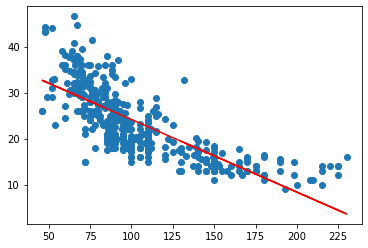

In [126]:
plt.plot(X,yhat, c= 'red')
plt.scatter(X,y)

In [112]:
y-yhat

ValueError: operands could not be broadcast together with shapes (391,1) (392,1) 

## K-fold pictures 

In [15]:
n = 30 
K = 5

for i in range(K):
    U = np.array(range(30))
    np.random.shuffle(U)

    V = np.ones(n)
    V[i*int(n/K):(i+1)*int(n/K)] = 0

    plt.matshow(V.reshape(1,-1),cmap = 'YlOrRd')
    ax = plt.gca()
    ax.axes.yaxis.set_visible(False)

    plt.xticks(list(range(n)), U)
    
    if i>0:
        ax.axes.xaxis.set_visible(False)
    plt.savefig('CV-Kfold-subset'+str(i)+'.png', bbox_inches = 'tight')
    
    plt.clf()

<Figure size 1152x144 with 0 Axes>

<Figure size 1152x144 with 0 Axes>

<Figure size 1152x144 with 0 Axes>

<Figure size 1152x144 with 0 Axes>

<Figure size 1152x144 with 0 Axes>